In [1]:
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import os
import torch
import matplotlib.pyplot as plt
from captum.attr import LayerDeepLift
from skimage.segmentation import mark_boundaries
from lime import lime_image
from lime.wrappers.scikit_image import SegmentationAlgorithm
import shap
from IPython.display import display, HTML

In [2]:

# Directory to save model checkpoints
save_dir = './checkpoints'
os.makedirs(save_dir, exist_ok=True)
#Save model after each epoch
def save_model(model, optimizer, avg_loss, test_accuracy, epoch):
        checkpoint_path = os.path.join('./checkpoints', f'model_epoch_{epoch + 1}.pth')
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
            'accuracy': test_accuracy
        }, checkpoint_path)

        print(f'Model saved at {checkpoint_path}')

In [3]:
#Active Conda Environment: condaPyProj311
conda_env = os.getenv("CONDA_DEFAULT_ENV")
print(f"dflt Conda Environment: {conda_env}")
# Get the path of the active conda environment
conda_env_path = os.getenv("CONDA_PREFIX")
if conda_env_path:
    # Extract the environment name from the path
    conda_env_name = os.path.basename(conda_env_path)
    print(f"Active Conda Environment: {conda_env_name}")
else:
    print("No active Conda environment")
from torchvision.datasets import ImageFolder
FIG_SIZE = (12,6)
output_directory = "./explained_images/"
os.makedirs(output_directory, exist_ok=True)  # Create the directory if it doesn't exist
class ImageFolderWithFilenames(ImageFolder):
    def __getitem__(self, index):
        # Get the original tuple of (image, label)
        original_tuple = super().__getitem__(index)
        # Get the image path and extract the filename
        path, _ = self.samples[index]
        filename = os.path.basename(path)
        # Return image, label, and filename
        return original_tuple[0], original_tuple[1], filename

dflt Conda Environment: condaPyProj311
Active Conda Environment: condaPyProj311


In [4]:
train_loss_list = []
test_accuracy_list = []
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')  # Prints 'cuda' if GPU is available, else 'cpu'

batch_size = 64
learning_rate = 0.001
num_epochs = 5
image_size = (480, 960)  # Image size
color_channel = 3 # only grayscale, so 1 channel is enough

# Define the transformations (resize, normalize, convert to tensor)
transform = transforms.Compose([
    transforms.Resize(image_size),  # Resize images to 960x480 pixels
    #transforms.Grayscale(num_output_channels=color_channel),  # Convert to grayscale (1 channel)
    transforms.ToTensor(),  # Convert the image to PyTorch tensor
    #transforms.Normalize((0.5), (0.5))  # Normalize the image between -1 and 1
])

# Load the datasets
# train_dataset = ImageFolderWithFilenames(root='/home/zubair/Downloads/CNN Data/Training Images white', transform=transform)
# train_dataset = ImageFolderWithFilenames(root='/home/zubair/Downloads/CNN Data/Training Images Black', transform=transform)
train_dataset = ImageFolderWithFilenames(root='/home/zubair/Downloads/CNN Data/Training Images Combined', transform=transform)

# test_dataset = ImageFolderWithFilenames(root='/home/zubair/Downloads/CNN Data/Test Images White', transform=transform)
# test_dataset = ImageFolderWithFilenames(root='/home/zubair/Downloads/CNN Data/Test Images Black', transform=transform)
test_dataset = ImageFolderWithFilenames(root='/home/zubair/Downloads/CNN Data/Test Images Combined', transform=transform)

# DataLoader (to handle batch processing)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)

Using device: cuda


In [5]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # shap expects CNN  to have self.conv_layers and self.fc_layers
        # Define the convolutional layers using nn.Sequential
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=color_channel, out_channels=16, kernel_size=3, stride=1, padding=1, device=device),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1, device=device),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1, device=device),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1, device=device),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1, device=device),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Calculate the size of the flattened output after conv + pooling
        conv_output_size = self._get_conv_output_size(image_size)

        # Define the fully connected layers using nn.Sequential
        self.fc_layers = nn.Sequential(
            nn.Linear(conv_output_size, 512),  # First fully connected layer
            nn.ReLU(),
            #nn.Dropout(),  # Add dropout for regularization
            # nn.Linear(conv_output_size * 2, conv_output_size * 4),  # First fully connected layer
            # nn.ReLU(),
            # 
            # nn.Linear(conv_output_size * 4, conv_output_size * 8),  # First fully connected layer
            # nn.ReLU(),
            
            nn.Linear(512, len(train_dataset.classes))  # Output layer
        )

    def forward(self, x):
        x = self.conv_layers(x)  # Pass through convolutional layers
        x = x.reshape(x.size(0), -1)  # Flatten the tensor
        x = self.fc_layers(x)  # Pass through fully connected layers
        return x
    #for tsne experiment
    def forward_features(self, x):
        x = self.conv_layers(x)  # Get feature output from conv layers
        x = x.reshape(x.size(0), -1)  # Flatten
        return x

    def _get_conv_output_size(self, img_size):
        """Helper function to calculate the size of the tensor after conv + pool."""
        with torch.no_grad():
            dummy_input = torch.ones(1, color_channel, *img_size).to(device)  # Dummy input
            x = self.conv_layers(dummy_input)  # Pass through conv layers
            return x.numel()  # Return the flattened size
    
    
    #for gradcamDeep
    def activations_hook(self, grad):
        self.gradients = grad  # Store gradients

    def get_activations_gradient(self):
        return self.gradients

    def get_activations(self, x):
        return self.conv_layers(x)

In [6]:
model = SimpleCNN().to(device)  # Move the model to the GPU/CPU
criterion = nn.CrossEntropyLoss()  # Cross entropy loss for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Modify the training function to save loss, accuracy, and model
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs, device):
    model.train()  # Set the model to training mode
    for epoch in range(num_epochs):
        running_loss = 0.0
        # Training loop
        for images, labels, filenames in train_loader:
            images, labels = images.to(device), labels.to(device)  # Move data to the GPU/CPU
            optimizer.zero_grad()  # Zero the gradients
            outputs = model(images)  # Forward pass
            loss = criterion(outputs, labels)  # Compute the loss
            loss.backward()  # Backpropagation
            optimizer.step()  # Update the weights
            running_loss += loss.item()
        # Average loss for the epoch
        avg_loss = running_loss / len(train_loader)
        train_loss_list.append(avg_loss)
        print(f'Epoch [{epoch + 1}/{num_epochs}], Train Loss: {avg_loss:.4f}')
        # Test accuracy at the end of each epoch
        test_accuracy = test_model(model, test_loader, device)
        test_accuracy_list.append(test_accuracy)
        # save_model(model, optimizer, avg_loss, test_accuracy, epoch);
    return train_loss_list, test_accuracy_list

# Modify the test function to return accuracy
def test_model(model, test_loader, device):
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0

    with torch.no_grad():  # No need to track gradients for testing
        for images, labels, fileNames in test_loader:
            images, labels = images.to(device), labels.to(device)  # Move data to the GPU/CPU
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy of the model on the test images: {accuracy:.2f}%')
    return accuracy

# Train the model and save metrics
train_loss_list, test_accuracy_list = train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs, device)

Epoch [1/5], Train Loss: 0.6589
Accuracy of the model on the test images: 82.44%
Epoch [2/5], Train Loss: 0.2056
Accuracy of the model on the test images: 86.88%
Epoch [3/5], Train Loss: 0.0829
Accuracy of the model on the test images: 85.23%
Epoch [4/5], Train Loss: 0.0318
Accuracy of the model on the test images: 91.43%
Epoch [5/5], Train Loss: 0.0108
Accuracy of the model on the test images: 89.46%


/home/zubair/miniconda3/envs/condaPyProj311/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:800: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/home/zubair/miniconda3/envs/condaPyProj311/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


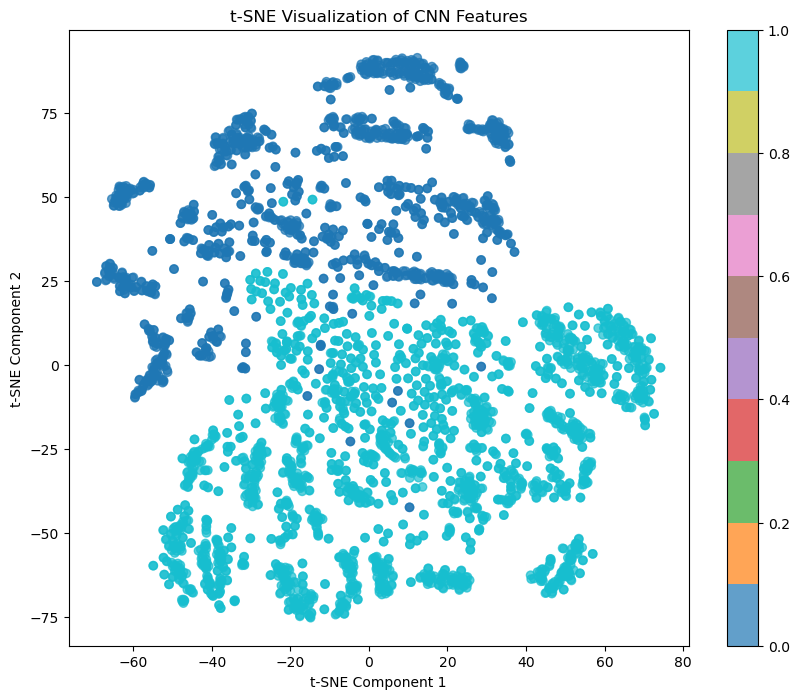

In [7]:
from matplotlib.colors import ListedColormap  #for tsne experiment
def extract_features_from_model(dataloader, model, device):
    model.eval()  # Set to evaluation mode
    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels, _ in dataloader:
            images, labels = images.to(device), labels.to(device)
            features = model.forward_features(images)  # Extract features before FC layer
            all_features.append(features.cpu().numpy())  # Convert to CPU and numpy
            all_labels.append(labels.cpu().numpy())  # Convert to CPU and numpy

    all_features = np.concatenate(all_features, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    return all_features, all_labels

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def visualize_tsne(features, labels, num_classes):
    tsne = TSNE(n_components=2, random_state=42)
    reduced_features = tsne.fit_transform(features)

    # Create a scatter plot with class labels
    plt.figure(figsize=(10, 8))
    cmap = ListedColormap(['red', 'blue', 'green', 'yellow'])

    scatter = plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=labels, cmap='tab10', alpha=0.7)
    plt.colorbar(scatter)
    plt.title('t-SNE Visualization of CNN Features')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.show()

# Extract features from the training set
features, labels = extract_features_from_model(train_loader, model, device)

# Visualize t-SNE on the extracted features
visualize_tsne(features, labels, len(train_dataset.classes))


In [8]:
# Plot correct and incorrect predictions
def plot_images(images, labels, predictions, title, maxNumberOfImage):
    rows, cols = calculate_grid_size(maxNumberOfImage)
    plt.figure(figsize=(cols * 30, rows * 15))
    for i in range(maxNumberOfImage): # len(images)
        plt.subplot(rows, cols, i + 1)
        imshow(images[i])
        plt.title(f'Pred: {predictions[i]}, Actual: {labels[i]}')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

# Helper function to display images
def imshow(img, truelabel, predicted_label, fileName):
    # img = img / 2 + 0.5  # Unnormalize the image
    # npimg = img.cpu().numpy()  # Ensure the tensor is on the CPU before displaying
    # plt.imshow(np.transpose(npimg, (1, 2, 0)))
    #img = img / 2 + 0.5  # Unnormalize the image
    npimg = img.cpu().numpy()  # Ensure the tensor is on the CPU before displaying
    npimg=npimg.transpose((1, 2, 0))
    #npimg = npimg.squeeze()  # Remove the channel dimension (from (1, H, W) to (H, W))
    plt.title(f"Orignal image: True Label: {truelabel}, Predicted Label: {predicted_label}, fileName: {fileName}")
    plt.figure(figsize=FIG_SIZE)
    plt.imshow(npimg) 

In [9]:
target_layer = model.conv_layers[-1]
cam = GradCAM(model=model, target_layers=[target_layer])
def showGradcamOuputput(input_image, truelabel, predictedLabel, fileName, imageIndex):
    input_image = input_image.unsqueeze(0)  # add batch as first dim, so Shape becomes (1, 1, H, W)
    input_image = input_image.to(device)
    grayscale_cam = cam(input_tensor=input_image, targets=None)[0]  # No need to specify target for single-label dataset
    # Convert the input image to a NumPy array for visualization
    input_image_np = input_image.squeeze(0).cpu().numpy()  # Remove batch and channel dimensions
    input_image_np = (input_image_np - input_image_np.min()) / (input_image_np.max() - input_image_np.min())  # Normalize [0, 1]
    input_image_np = input_image_np.transpose((1, 2, 0))
    # Overlay the heatmap
    visualization = show_cam_on_image(input_image_np, grayscale_cam, use_rgb=True)

    plt.figure(figsize=FIG_SIZE)  # Adjust aspect ratio (12:6 = 960:480 for 80 dpi)
    plt.imshow(visualization)
    plt.title(f"Grad-CAM Heatmap: truelabel: {truelabel}, predictedLabel: {predictedLabel}, fileName: {fileName}")
    plt.axis("off")
    plt.savefig(os.path.join(output_directory, f"gradCam_black_background{imageIndex}.png"), dpi=300)
    plt.show()

In [10]:
import torch.nn.functional as F

model.eval()  # Set the model to evaluation mode
# Initialize LayerDeepLift for the specified layer
lrp = LayerDeepLift(model, model.conv_layers[-1])
# Function to apply LRP and generate the relevance map
def apply_lrp(model, input_tensor, target_class, layer):
    """
    Applies Layer-wise Relevance Propagation (LRP) using LayerDeepLift.
    Args:
        model: Trained PyTorch model.
        input_tensor: Input image tensor of shape (1, 1, H, W).
        target_class: Class index for which relevance is computed.
        layer: The specific model layer to analyze.
    Returns:
        relevance_map: Aggregated relevance map as a NumPy array (2D).
    """
    # Compute relevance attributions
    attributions = lrp.attribute(input_tensor, target=target_class)  # Shape: (1, C, H, W)
    # Aggregate across the channel dimension (e.g., sum across channels)
    relevance_map = attributions.squeeze(0).sum(dim=0).cpu().detach().numpy()  # Shape: (H, W)
    return relevance_map

# Function to visualize and save LRP heatmaps
def show_lrp_output(input_image, truelabel, predicted_label, fileName, image_index):
    input_image = input_image.unsqueeze(0).to(device)  # Add batch dimension and move to devic
    # Select the layer for LRP (e.g., the last convolutional layer)
    target_layer = model.conv_layers[-1]  # Adjust this based on your model architecture
    # Generate the relevance map using LRP
    relevance_map = apply_lrp(model, input_image, target_class=predicted_label, layer=target_layer)
    # Normalize the relevance map for visualization
    relevance_map_normalized = (relevance_map - relevance_map.min()) / (relevance_map.max() - relevance_map.min())
    # Optional: Upsample the relevance map to match the input image size
    relevance_map_resized = F.interpolate(
        torch.tensor(relevance_map_normalized).unsqueeze(0).unsqueeze(0),
        size=image_size, mode='bilinear'
    ).squeeze().numpy()
    # Visualize the LRP heatmap
    plt.figure(figsize=FIG_SIZE)
    plt.imshow(relevance_map_resized, cmap='hot', interpolation='nearest', aspect='auto')
    #plt.imshow(relevance_map_resized, cmap='hot', interpolation='nearest')
    plt.colorbar(label='Relevance')
    plt.title(f"LRP Heatmap: True Label: {truelabel}, Predicted Label: {predicted_label}, fileName: {fileName}")
    plt.axis("off")
    # Save the heatmap
    os.makedirs("explained_images", exist_ok=True)
    plt.savefig(os.path.join(output_directory, f"lrp_heatmap_{image_index}.png"), dpi=300)
    plt.show()

In [11]:
# loader = torch.utils.data.DataLoader(test_dataset, batch_size=30, shuffle=True)
# loader_imagesNLabels = next(iter(loader))
# images, labels, image_file_names = loader_imagesNLabels  # Get the first batch of images
# for i, test_image in enumerate(images):
#     # ouptutForShap(shap_values, test_image, test_labels[i], tets_image_fileNames[i], i)
#     # showLimeOutput(explainer, lime_cnn_model_wrapper, segmentation_fn, test_image, test_labels[i], tets_image_fileNames[i], i)
#     outputs = model(test_image.unsqueeze(0).to(device))  # Add batch dimension and move to device
#     _, predicted = torch.max(outputs.data, 1)  # Get predicted label
# 
#     # Call showGradcamOuputput with true label, predicted label, and other details
#     imshow(test_image, labels[i], predicted.item(), image_file_names[i])
#     #visualize_reverse_normalization(test_image)
#     showGradcamOuputput(test_image, labels[i], predicted.item(), image_file_names[i], i)
#     show_lrp_output(test_image, labels[i], predicted.item(), image_file_names[i], i)

In [ ]:
model.eval()
shap_loader_batch_size= 100
shap_background_batch_size = 80
shap_loader = torch.utils.data.DataLoader(train_dataset, batch_size=shap_loader_batch_size, shuffle=True)
shap_loader_batch = next(iter(shap_loader))
shap_background_images =  shap_loader_batch[0][:shap_background_batch_size]
shap_test_batch_images, shap_test_batch_labels, shap_test_batch_images_fileNames = shap_loader_batch[0][shap_background_batch_size:],shap_loader_batch[1][shap_background_batch_size:], shap_loader_batch[2][shap_background_batch_size:]
print("shap_background_images " + type(shap_background_images) + "shape " + type(shap_background_images).shape)
e = shap.DeepExplainer(model.cpu(), shap_background_images)
shap_values = e.shap_values(shap_test_batch_images.cpu())  #batch, channel,h ,w, class
shap_values = np.transpose(shap_values, (4, 0, 2, 3, 1))  #class, batch, h ,w, channel
shap_values = list(shap_values)  #class list of each batch, h ,w, channel

def ouptutForShap(shap_values, test_image, truelabel, predictedLabel, fileName, imageIndex):
    shap_pixel_values = np.swapaxes(test_image.numpy(), 0, -1)  #b,h,w,c
    shap_pixel_values = np.swapaxes(shap_pixel_values, 0, 1)
    shap_pixel_values = np.expand_dims(shap_pixel_values, axis=0)
    shap.image_plot(shap_values, shap_pixel_values,  show = False) #  , labels=['predictedLabels11' , 'predictedLabels22'], true_labels = ['trueLabels11']
    plt.gcf().set_size_inches(20, 10)  # Set the figure size to be larger
    plt.suptitle(f"SHAP {fileName},actual:{truelabel}, predict:{predictedLabel}", fontsize=20)  # Add a title with custom font size
    plt.savefig(os.path.join(output_directory, f"shap_image_{imageIndex}.png"), dpi=300)
    plt.show()

In [21]:
class LimeCNNWrapper:
    def __init__(self, model, device):
        self.model = model
        self.device = device
    def predict(self, images):
        # Convert numpy image (batch) to tensor; now images are batch, h, w, c : 10, 960, 480, 3
        # lime sends as batch, h, w, c ;; now average on channel dim, as lime is forefully sending 3 channels.
        # comment below if u actually have 3 channel image
        # if images.shape[-1] == 3:
        #     images = np.mean(images, axis=-1, keepdims=True)
        images = torch.tensor(images).permute(0, 3, 1, 2).float()  # Convert to (batch, channels, height, width);; cuz my predict fun expects this format
        images = images.to(self.device)
        with torch.no_grad():
            outputs = self.model(images)
            probabilities = torch.nn.functional.softmax(outputs, dim=1).cpu().numpy()
        return probabilities
    
# Initialize LIME explainer
explainer = lime_image.LimeImageExplainer()
# Create a wrapper for the model
model = model.to(device)
lime_cnn_model_wrapper = LimeCNNWrapper(model, device)
# Create a SegmentationAlgorithm object with 'slic' algorithm
segmentation_fn = SegmentationAlgorithm('slic', n_segments=100, compactness=1, sigma=1)
def showLimeOutput(limeExplainer, limeCNNWrapper, segmentation_fn, test_image, test_label, fileName, imageIndex):
    if test_label is not None:
        image, label = test_image, test_label  # Get one image from your test dataset
    else :
        image, label = test_image
    image_np = image.numpy().transpose(1, 2, 0)  # Convert tensor to numpy for LIME
    image_np = np.squeeze(image_np) # remove channel dimension
    # Explain the model's prediction for this specific image
    explanation = limeExplainer.explain_instance(image_np, 
                                             limeCNNWrapper.predict, 
                                             top_labels=2, 
                                             hide_color=0, 
                                             num_samples=100,
                                             segmentation_fn=segmentation_fn)
    temp, mask = explanation.get_image_and_mask(explanation.top_labels[0],
                                                positive_only=False,
                                                num_features=5,
                                                hide_rest=False)
    # Display the image with explanations
    img_boundaries = mark_boundaries(temp, mask, color = (0, 0, 1))
    plt.figure(figsize=FIG_SIZE)
    plt.imshow(img_boundaries )  # Unnormalize the image
    #plt.imshow(img_boundaries / 2 + 0.5 )  # Unnormalize the image
    plt.axis('off')
    plt.title(f'LIME Explanation-> TrueLabel: {label}, prediction: {explanation.top_labels[0]}, fileName: {fileName}')
    plt.savefig(os.path.join(output_directory, f"lime_image_{imageIndex}.png"), dpi=300)
    plt.show()

In [ ]:

for i, test_smaple in enumerate(shap_test_batch_images):
    testing_image, test_label, test_fileName = shap_test_batch_images[i], shap_test_batch_labels[i], shap_test_batch_images_fileNames[i]
    outputs = model(testing_image.unsqueeze(0).to(device))  # Add batch dimension and move to device
    _, predicted = torch.max(outputs.data, 1)  # Get predicted label
    predicted_label = predicted.item()
    #imshow(testing_image, test_label, predicted.item(), test_fileName)
    ouptutForShap(shap_values, testing_image, test_label, predicted_label, test_fileName, i)
    showLimeOutput(explainer, lime_cnn_model_wrapper, segmentation_fn, testing_image, test_label, test_fileName, i)
    showGradcamOuputput(testing_image, test_label, predicted_label, test_fileName, i)
    show_lrp_output(testing_image, test_label, predicted_label, test_fileName, i)

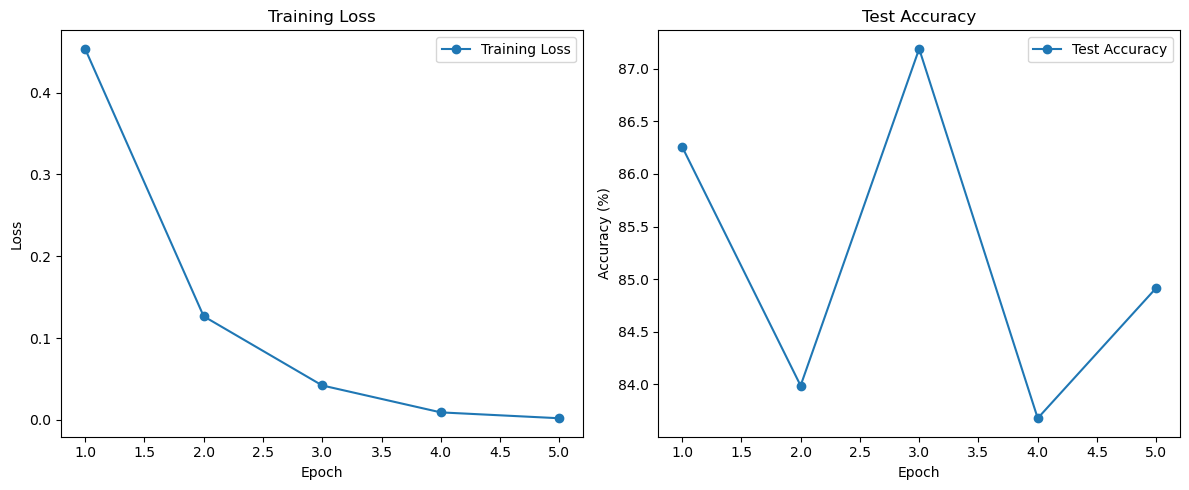

In [24]:
# Function to plot the loss and accuracy
def plot_metrics(train_loss_list, test_accuracy_list):
    epochs = range(1, len(train_loss_list) + 1)

    # Plot Loss
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss_list, '-o', label='Training Loss')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, test_accuracy_list, '-o', label='Test Accuracy')
    plt.title('Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()
    
    
# Plot loss and accuracy
plot_metrics(train_loss_list, test_accuracy_list)


In [25]:

    
# Testing function that plots correct and incorrect predictions
def test_model_with_plots(model, test_loader, device='cpu', maxNumberOfImage = 9):
    model.eval()  # Set the model to evaluation mode
    correct_images, incorrect_images = [], []
    correct_labels, incorrect_labels = [], []
    correct_preds, incorrect_preds = [], []

    with torch.no_grad():  # No need to track gradients for testing
        for images, labels, fileNames in test_loader:
            images, labels = images.to(device), labels.to(device)  # Move data to the GPU/CPU
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            for i in range(len(labels)):
                if predicted[i] == labels[i] :
                    correct_images.append(images[i])
                    correct_labels.append(labels[i].item())
                    correct_preds.append(predicted[i].item())
                elif predicted[i] != labels[i] :
                    incorrect_images.append(images[i])
                    incorrect_labels.append(labels[i].item())
                    incorrect_preds.append(predicted[i].item())

    print(f'Accuracy of the model on the test images: {100 * len(correct_images) / len(test_loader.dataset):.2f}%')
    # Plot correct predictions
    plot_images(correct_images, correct_labels, correct_preds, 'Correct Predictions', maxNumberOfImage)
    # Plot incorrect predictions
    plot_images(incorrect_images, incorrect_labels, incorrect_preds, 'Incorrect Predictions', maxNumberOfImage)


import math
def calculate_grid_size(n_images):
    cols = math.ceil(math.sqrt(n_images))  # Number of columns
    rows = math.ceil(n_images / cols)      # Number of rows based on columns
    return rows, cols

# Test the model and plot correct and incorrect predictions

In [ ]:
html = "<table>"
num_of_image_toShow = 20
grad_images = [os.path.join("explained_images/", f"gradCam_black_background{i}.png") for i in range(num_of_image_toShow)]  # Full paths to images
lime_images = [os.path.join("explained_images/", f"lime_image_{i}.png") for i in range(num_of_image_toShow)]  # Full paths to images
shap_images = [os.path.join("explained_images/", f"shap_image_{i}.png") for i in range(num_of_image_toShow)]  # Full paths to images
lrp_images = [os.path.join("explained_images/", f"lrp_heatmap_{i}.png") for i in range(num_of_image_toShow)]  # Full paths to images
STYLE='width:1200px;height:600px;'
html ="<table>"
for img_index in range(num_of_image_toShow):
        html += "<tr>"
        html += f"<td><img src='{grad_images[img_index]}' style={STYLE}></td>"
        html += f"<td><img src='{lrp_images[img_index]}' style={STYLE}></td>"
        html += "</tr>"
        html += "<tr>"
        html += f"<td><img src='{shap_images[img_index]}' style={STYLE}></td>"
        html += f"<td><img src='{lime_images[img_index]}' style={STYLE}></td>"
        html += "</tr>"

html += "</table>"
display(HTML(html))


In [ ]:
import torch
import numpy as np
from captum.attr import (
    GuidedGradCam,
    Saliency,
    IntegratedGradients,
    LayerGradCam,
    GradientShap
)
import matplotlib.pyplot as plt
from torchvision import transforms

def get_attribution_map(model, input_tensor, target_class, method='guided_gradcam'):
    """
    Generate attribution maps using different XAI methods
    
    Args:
        model: trained CNN model
        input_tensor: input image tensor
        target_class: target class index
        method: XAI method to use
    """
    model.eval()
    input_tensor.requires_grad = True
    
    if method == 'guided_gradcam':
        # GuidedGradCAM for detailed feature visualization
        guided_gc = GuidedGradCam(model, model.conv_layers[-2])
        attribution = guided_gc.attribute(input_tensor, target=target_class)
    
    elif method == 'integrated_gradients':
        # Integrated Gradients for feature importance
        ig = IntegratedGradients(model)
        attribution = ig.attribute(input_tensor, target=target_class, n_steps=50)
    
    elif method == 'gradientshap':
        # GradientShap for comparing feature importance across classes
        gs = GradientShap(model)
        baseline = torch.zeros_like(input_tensor)
        attribution = gs.attribute(input_tensor, baselines=baseline, target=target_class)
    
    return attribution

def visualize_attribution(original_image, attribution, title="Attribution Map"):
    """
    Visualize the attribution map overlaid on the original image
    """
    # Convert attribution to numpy and take absolute value
    attribution = np.abs(attribution.squeeze().cpu().detach().numpy())
    
    # Normalize attribution scores
    attribution = (attribution - attribution.min()) / (attribution.max() - attribution.min())
    
    # Create heatmap
    plt.figure(figsize=(15, 5))
    
    # Original image
    plt.subplot(1, 3, 1)
    plt.imshow(original_image.squeeze().cpu().detach().numpy().transpose(1, 2, 0))
    plt.title("Original Spectrogram")
    plt.axis('off')
    
    # Attribution map
    plt.subplot(1, 3, 2)
    # i added
    attribution = np.transpose(attribution, (1, 2, 0))
    plt.imshow(attribution, cmap='hot')
    plt.title(f"{title}")
    plt.axis('off')
    
    # Overlay
    plt.subplot(1, 3, 3)
    plt.imshow(original_image.squeeze().cpu().detach().numpy().transpose(1, 2, 0))
    plt.imshow(attribution, cmap='hot', alpha=0.5)
    plt.title("Overlay")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

def analyze_single_prediction(model, image_tensor, class_name, class_idx):
    """
    Analyze a single prediction using multiple XAI methods
    """
    # Generate attribution maps using different methods
    methods = ['guided_gradcam', 'integrated_gradients', 'gradientshap']
    
    for method in methods:
        attribution = get_attribution_map(
            model, 
            image_tensor.unsqueeze(0), 
            target_class=class_idx, 
            method=method
        )
        visualize_attribution(
            image_tensor, 
            attribution, 
            f"{method.replace('_', ' ').title()} - {class_name}"
        )

def analyze_model_predictions(model, test_loader, device, num_samples=5):
    """
    Analyze model predictions on test data
    """
    model.eval()
    analyzed_count = 0
    
    with torch.no_grad():
        for images, labels, filenames in test_loader:
            if analyzed_count >= num_samples:
                break
                
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            
            # Analyze correct predictions
            correct_mask = predicted == labels
            correct_images = images[correct_mask]
            correct_labels = labels[correct_mask]
            
            for img, label in zip(correct_images, correct_labels):
                if analyzed_count >= num_samples:
                    break
                    
                class_name = test_loader.dataset.classes[label]
                analyze_single_prediction(model, img, class_name, label)
                analyzed_count += 1
                print(f"\nAnalysis for class: {class_name}")
                print("-" * 50)

# Function to analyze feature importance across classes
def analyze_feature_importance(model, test_loader, device):
    """
    Analyze and compare feature importance across different classes
    """
    model.eval()
    class_attributions = {}
    
    for images, labels, _ in test_loader:
        images, labels = images.to(device), labels.to(device)
        
        for img, label in zip(images, labels):
            class_name = test_loader.dataset.classes[label.item()]
            
            if class_name not in class_attributions:
                attribution = get_attribution_map(
                    model, 
                    img.unsqueeze(0), 
                    target_class=label.item(),
                    method='integrated_gradients'
                )
                class_attributions[class_name] = attribution.abs().mean().item()
    
    # Plot feature importance by class
    plt.figure(figsize=(24, 12))
    classes = list(class_attributions.keys())
    importances = list(class_attributions.values())
    
    plt.bar(classes, importances)
    plt.xticks(rotation=45, ha='right')
    plt.title('Average Feature Importance by Class')
    plt.ylabel('Attribution Magnitude')
    plt.tight_layout()
    plt.show()

# Usage example
    # Analyze model predictions
analyze_model_predictions(model, test_loader, device, num_samples=3)

# Analyze feature importance across classes
analyze_feature_importance(model, test_loader, device)

In [28]:
class SimpleCNNForGradCam(nn.Module):
    def __init__(self):
        super(SimpleCNNForGradCam, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=color_channel, out_channels=16, kernel_size=3, stride=1, padding=1, device=device),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1, device=device),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1, device=device),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1, device=device),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1, device=device),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(self._get_conv_output_size(image_size), 512),
            nn.ReLU(),
            
            nn.Linear(512, 1024),
            nn.ReLU(),
            
            nn.Linear(1024, len(train_dataset.classes))
        )

        # Placeholder for feature maps and gradients
        self.feature_maps = None
        self.gradients = None

    def forward(self, x):
        x = self.conv_layers(x)
        self.feature_maps = x  # Store feature maps
        x.register_hook(self.activations_hook)  # Register hook to store gradients
        x = x.reshape(x.size(0), -1)
        x = self.fc_layers(x)
        return x

    def _get_conv_output_size(self, img_size):
        with torch.no_grad():
            dummy_input = torch.ones(1, color_channel, *img_size).to(device)
            x = self.conv_layers(dummy_input)
            return x.numel()

    def activations_hook(self, grad):
        self.gradients = grad  # Store gradients

    def get_activations_gradient(self):
        return self.gradients

    def get_activations(self, x):
        return self.conv_layers(x)

In [29]:
modelForGradCam = SimpleCNNForGradCam().to(device)  # Move the model to the GPU/CPU
criterionForGradCam = nn.CrossEntropyLoss()  # Cross entropy loss for multi-class classification
optimizerForGradCam = optim.Adam(modelForGradCam.parameters(), lr=learning_rate)

# Modify the training function to save loss, accuracy, and model
def train_model_ForGradCam(model, train_loader, test_loader, criterion, optimizer, num_epochs, device):
    model.train()  # Set the model to training mode
    for epoch in range(num_epochs):
        running_loss = 0.0
        # Training loop
        for images, labels, filenames in train_loader:
            images, labels = images.to(device), labels.to(device)  # Move data to the GPU/CPU
            optimizer.zero_grad()  # Zero the gradients
            outputs = model(images)  # Forward pass
            loss = criterion(outputs, labels)  # Compute the loss
            loss.backward()  # Backpropagation
            optimizer.step()  # Update the weights
            running_loss += loss.item()
        # Average loss for the epoch
        avg_loss = running_loss / len(train_loader)
        train_loss_list.append(avg_loss)
        print(f'Epoch [{epoch + 1}/{num_epochs}], Train Loss: {avg_loss:.4f}')
        # Test accuracy at the end of each epoch
        test_accuracy = test_model(model, test_loader, device)
        test_accuracy_list.append(test_accuracy)
        # save_model(model, optimizer, avg_loss, test_accuracy, epoch);
    return train_loss_list, test_accuracy_list

# Modify the test function to return accuracy
def test_model(model, test_loader, device):
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0

    # with torch.no_grad():  # No need to track gradients for testing
    for images, labels, fileNames in test_loader:
        images, labels = images.to(device), labels.to(device)  # Move data to the GPU/CPU
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy of the model on the test images: {accuracy:.2f}%')
    return accuracy

train_loss_list_ForGradCam, test_accuracy_list_ForGradCam = train_model_ForGradCam(modelForGradCam, train_loader, test_loader, criterionForGradCam, optimizerForGradCam, num_epochs, device)


Epoch [1/5], Train Loss: 0.4458
Accuracy of the model on the test images: 84.40%
Epoch [2/5], Train Loss: 0.1132
Accuracy of the model on the test images: 87.40%
Epoch [3/5], Train Loss: 0.0412
Accuracy of the model on the test images: 90.60%
Epoch [4/5], Train Loss: 0.0205
Accuracy of the model on the test images: 85.95%
Epoch [5/5], Train Loss: 0.0217
Accuracy of the model on the test images: 86.78%


In [30]:
def grad_cam(model, image, target_class):
    model.eval()
    image = image.unsqueeze(0).to(device)  # Add batch dimension and move to device

    # Forward pass
    output = model(image)
    model.zero_grad()

    # Backward pass for the target class
    one_hot = torch.zeros_like(output)
    one_hot[0][target_class] = 1
    output.backward(gradient=one_hot)

    # Get gradients and feature maps
    gradients = model.get_activations_gradient()
    feature_maps = model.feature_maps

    # Pool the gradients and weight the feature maps
    pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])
    for i in range(feature_maps.size(1)):
        feature_maps[:, i, :, :] *= pooled_gradients[i]

    # Generate the heatmap
    heatmap = torch.mean(feature_maps, dim=1).squeeze()
    heatmap = torch.relu(heatmap)  # Apply ReLU to the heatmap
    heatmap /= torch.max(heatmap)  # Normalize the heatmap

    return heatmap.detach().cpu().numpy()

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def visualize_grad_cam(image, heatmap, label, filename):
    # Resize heatmap to match the image size
    heatmap = cv2.resize(heatmap, (image.shape[2], image.shape[1]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Superimpose the heatmap on the image
    superimposed_img = heatmap * 0.4 + image.squeeze().permute(1, 2, 0).cpu().numpy() * 255
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    plt.figure(figsize=(24,12))  # Adjust aspect ratio (12:6 = 960:480 for 80 dpi)
    plt.title(f"Grad-CAM Heatmap: truelabel: {label}, predictedLabel: dont care, fileName: {filename}")
    
    # Display the result
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.show()

# Example usage
images, labels, filenames = next(iter(test_loader))
for image,label, fielname in zip(images, labels, filenames):
    heatmap = grad_cam(modelForGradCam, image, label.item())
    visualize_grad_cam(image, heatmap, label, fielname)

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch

def grad_cam(model, image, target_class):
    model.eval()
    image = image.unsqueeze(0).to(device)  # Add batch dimension and move to device

    # Forward pass
    output = model(image)
    model.zero_grad()

    # Backward pass for the target class
    one_hot = torch.zeros_like(output)
    one_hot[0][target_class] = 1
    output.backward(gradient=one_hot)

    # Get gradients and feature maps
    gradients = model.get_activations_gradient()
    feature_maps = model.feature_maps

    # Pool the gradients and weight the feature maps
    pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])
    for i in range(feature_maps.size(1)):
        feature_maps[:, i, :, :] *= pooled_gradients[i]

    # Generate the heatmap
    heatmap = torch.mean(feature_maps, dim=1).squeeze()
    heatmap = torch.relu(heatmap)  # Apply ReLU to the heatmap
    heatmap /= torch.max(heatmap)  # Normalize the heatmap

    return heatmap.detach().cpu().numpy()

def visualize_grad_cam(image, heatmap, true_label, predicted_label, filename):
    # Resize heatmap to match the image size
    heatmap = cv2.resize(heatmap, (image.shape[2], image.shape[1]))
    heatmap = np.uint8(255 * heatmap)
    #heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_HOT)  # Alternative to JET


    # Superimpose the heatmap on the image
    original_img = image.squeeze().permute(1, 2, 0).cpu().numpy()  # Convert to HWC format
    original_img = (original_img * 255).astype(np.uint8)           # Scale pixel values

    superimposed_img = heatmap * 0.4 + original_img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    # Plotting original and Grad-CAM images side by side
    plt.figure(figsize=(30, 18))
    
    # Original Image
    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.title(f"Original Image\nTrue: {true_label}, Pred: {predicted_label}")
    plt.axis('off')

    # Grad-CAM Heatmap
    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title(f"Grad-CAM Heatmap\nFile: {filename}")
    plt.axis('off')

    #plt.tight_layout()
    plt.show()

# Example usage
images, labels, filenames = next(iter(test_loader))
for image, label, filename in zip(images, labels, filenames):
    image = image.to(device)
    
    # Get model prediction
    output = modelForGradCam(image.unsqueeze(0))  # Add batch dimension
    _, predicted = torch.max(output, 1)

    # Generate Grad-CAM heatmap
    heatmap = grad_cam(modelForGradCam, image, predicted.item())  # Use predicted class

    # Visualize original image and Grad-CAM
    visualize_grad_cam(image, heatmap, true_label=label.item(), predicted_label=predicted.item(), filename=filename)


In [ ]:
2# heapmaps per image

import matplotlib.pyplot as plt
import cv2
import numpy as np

def grad_cam(model, image, target_class):
    model.eval()
    image = image.unsqueeze(0).to(device)  # Add batch dimension and move to device

    # Forward pass
    output = model(image)
    model.zero_grad()

    # Backward pass for the target class
    one_hot = torch.zeros_like(output)
    one_hot[0][target_class] = 1
    output.backward(gradient=one_hot)

    # Get gradients and feature maps
    gradients = model.get_activations_gradient()
    feature_maps = model.feature_maps

    # Pool the gradients and weight the feature maps
    pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])
    for i in range(feature_maps.size(1)):
        feature_maps[:, i, :, :] *= pooled_gradients[i]

    # Generate the heatmap
    heatmap = torch.mean(feature_maps, dim=1).squeeze()
    heatmap = torch.relu(heatmap)  # Apply ReLU to the heatmap
    heatmap /= torch.max(heatmap)  # Normalize the heatmap

    return heatmap.detach().cpu().numpy()

def visualize_grad_cam(image, heatmap, label, predicted_label, filename):
    # Resize heatmap to match the image size
    heatmap_resized = cv2.resize(heatmap, (image.shape[2], image.shape[1]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)

    # Apply both colormaps
    heatmap_hot = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_HOT)
    heatmap_jet = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

    # Original image (convert tensor to NumPy)
    original_image = image.squeeze().permute(1, 2, 0).cpu().numpy() * 255
    original_image = np.clip(original_image, 0, 255).astype(np.uint8)

    # Superimpose heatmaps
    superimposed_hot = np.clip(heatmap_hot * 0.4 + original_image, 0, 255).astype(np.uint8)
    superimposed_jet = np.clip(heatmap_jet * 0.4 + original_image, 0, 255).astype(np.uint8)

    # Plotting side by side
    plt.figure(figsize=(18, 6))  # Adjust figure size

    # Original Image
    plt.subplot(1, 3, 1)
    plt.imshow(original_image)
    plt.title("Original Image")
    plt.axis('off')

    # Grad-CAM with HOT colormap
    plt.subplot(1, 3, 2)
    plt.imshow(superimposed_hot)
    plt.title("Grad-CAM (HOT)")
    plt.axis('off')

    # Grad-CAM with JET colormap
    plt.subplot(1, 3, 3)
    plt.imshow(superimposed_jet)
    plt.title("Grad-CAM (JET)")
    plt.axis('off')

    plt.suptitle(f"True Label: {label}, Predicted: {predicted_label}, File: {filename}", fontsize=14)
    plt.show()

# Example usage
images, labels, filenames = next(iter(test_loader))
for image, label, filename in zip(images, labels, filenames):
    heatmap = grad_cam(modelForGradCam, image, label.item())
    output = modelForGradCam(image.unsqueeze(0).to(device))
    _, predicted = torch.max(output, 1)

    visualize_grad_cam(image, heatmap, label.item(), predicted.item(), filename)
